In [1]:
import torch
import torch.distributions as D
from torch.distributions.kl import kl_divergence as KL
import matplotlib.pyplot as plt
import seaborn as sns

seed = 42
torch.manual_seed(seed)

# 1d gaussians

In [2]:
N = 1000
var_mus = torch.linspace(0, 10, N)
var_sigmas = torch.linspace(0.1, 10, N)

mus, sigmas = torch.meshgrid((var_mus, var_sigmas), indexing="ij")

In [3]:
mus

tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0100,  0.0100,  0.0100,  ...,  0.0100,  0.0100,  0.0100],
        [ 0.0200,  0.0200,  0.0200,  ...,  0.0200,  0.0200,  0.0200],
        ...,
        [ 9.9800,  9.9800,  9.9800,  ...,  9.9800,  9.9800,  9.9800],
        [ 9.9900,  9.9900,  9.9900,  ...,  9.9900,  9.9900,  9.9900],
        [10.0000, 10.0000, 10.0000,  ..., 10.0000, 10.0000, 10.0000]])

In [4]:
sigmas

tensor([[ 0.1000,  0.1099,  0.1198,  ...,  9.9802,  9.9901, 10.0000],
        [ 0.1000,  0.1099,  0.1198,  ...,  9.9802,  9.9901, 10.0000],
        [ 0.1000,  0.1099,  0.1198,  ...,  9.9802,  9.9901, 10.0000],
        ...,
        [ 0.1000,  0.1099,  0.1198,  ...,  9.9802,  9.9901, 10.0000],
        [ 0.1000,  0.1099,  0.1198,  ...,  9.9802,  9.9901, 10.0000],
        [ 0.1000,  0.1099,  0.1198,  ...,  9.9802,  9.9901, 10.0000]])

In [5]:
mus.shape, sigmas.shape

(torch.Size([1000, 1000]), torch.Size([1000, 1000]))

In [6]:
mus_flat = mus.reshape(-1, 1)
sigmas_flat = sigmas.reshape(-1, 1)

print(mus_flat.shape, sigmas_flat.shape)

torch.Size([1000000, 1]) torch.Size([1000000, 1])


In [7]:
var_normals = D.Normal(mus_flat, sigmas_flat)
fixed_normals = D.Normal(torch.zeros_like(mus_flat), torch.ones_like(sigmas_flat) / 10)

In [8]:
kl_val = KL(var_normals, fixed_normals)

In [9]:
kl_val.shape

torch.Size([1000000, 1])

In [10]:
kl_val_grid = kl_val.reshape(mus.shape)
print(kl_val_grid.shape)

torch.Size([1000, 1000])


Locator attempting to generate 1001 ticks ([0.0, ..., 10000.0]), which exceeds Locator.MAXTICKS (1000).


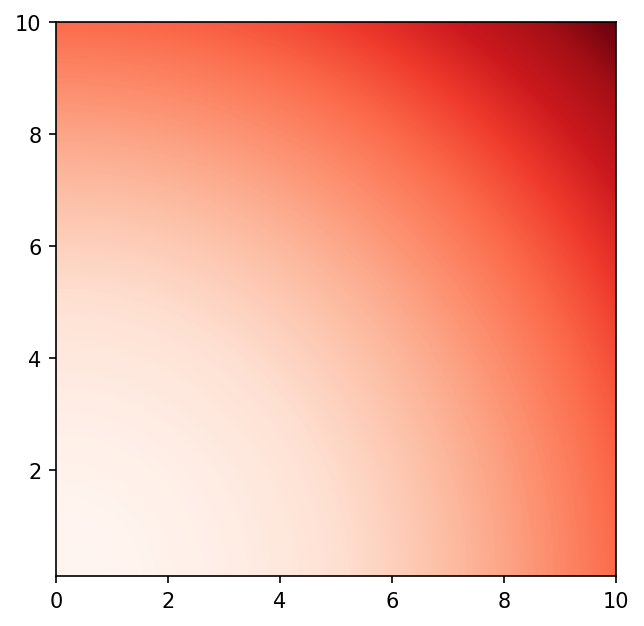

In [11]:
fig, ax = plt.subplots(dpi=150)
ax.contourf(mus, sigmas, kl_val_grid, levels=1000, cmap="Reds")
# make the plot square
ax.set_aspect('equal', 'box')

In [56]:
mus = torch.tensor([0., 1., 2.])
sigmas = torch.tensor([.1, .2, .3])

In [8]:
mus_grid, sigmas_grid = torch.meshgrid((mus, sigmas), indexing="ij")

In [9]:
means_all = mus_grid.flatten().reshape(-1, 1)

In [10]:
sigmas_all = sigmas_grid.flatten().reshape(-1, 1)

In [11]:
normal = D.Normal(means_all, sigmas_all)

In [12]:
normal

Normal(loc: torch.Size([9, 1]), scale: torch.Size([9, 1]))

In [13]:
base_normals = D.Normal(torch.zeros_like(means_all), torch.ones_like(sigmas_all) / 10)

In [14]:
kl_val = KL(normal, base_normals)

In [16]:
kl_val_grid = kl_val.reshape(mus_grid.shape)

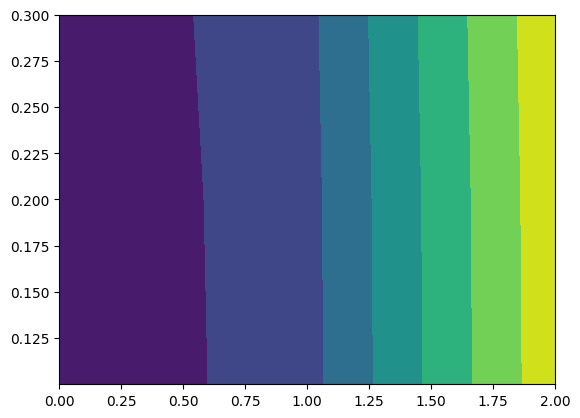

In [17]:
fig, ax = plt.subplots()
ax.contourf(mus_grid, sigmas_grid, kl_val_grid)

In [24]:
mus_grid_relative = mus_grid - torch.zeros_like(mus_grid)
sigmas_grid_relative = sigmas_grid - torch.ones_like(sigmas_grid)/10

In [25]:
mus_grid_relative

tensor([[0., 0., 0.],
        [1., 1., 1.],
        [2., 2., 2.]])

In [26]:
sigmas_grid_relative

tensor([[0.0000, 0.1000, 0.2000],
        [0.0000, 0.1000, 0.2000],
        [0.0000, 0.1000, 0.2000]])

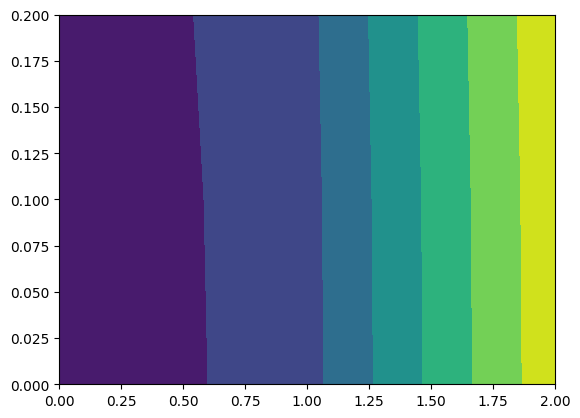

In [28]:
fig, ax = plt.subplots()
ax.contourf(mus_grid_relative, sigmas_grid_relative, kl_val_grid)

In [29]:
kl_val_grid

tensor([[  0.0000,   0.8069,   2.9014],
        [ 50.0000,  50.8069,  52.9014],
        [200.0000, 200.8069, 202.9014]])

In [30]:
mus_grid_relative

tensor([[0., 0., 0.],
        [1., 1., 1.],
        [2., 2., 2.]])

In [31]:
sigmas_grid_relative

tensor([[0.0000, 0.1000, 0.2000],
        [0.0000, 0.1000, 0.2000],
        [0.0000, 0.1000, 0.2000]])

In [34]:
kl_val_grid.flatten()

tensor([  0.0000,   0.8069,   2.9014,  50.0000,  50.8069,  52.9014, 200.0000,
        200.8069, 202.9014])